<a href="https://colab.research.google.com/github/abeliyasya/churn_analysis/blob/main/Analysis_Churn_by_Abel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.__version__


'2.2.3'

In [3]:
url_csv = "https://raw.githubusercontent.com/abeliyasya/churn_analysis/refs/heads/main/Churn.csv"

df_raw = pd.read_csv(url_csv,sep=";")
df_raw.shape


(10000, 11)

In [4]:
df_raw.isnull().sum()


,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


In [5]:
print("--- INFO DATASET ---")
print(f"Jumlah Baris & Kolom: {df_raw.shape}")
print("\nJumlah Missing Value per Kolom:")
print(df_raw.isnull().sum())

--- INFO DATASET ---
Jumlah Baris & Kolom: (10000, 11)

Jumlah Missing Value per Kolom:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [6]:
print("\n--- DISTRIBUSI TARGET (CHURN VS RETAINED) ---")
churn_counts = df_raw['Exited'].value_counts(normalize=True) * 100
print(f"Retained (0): {churn_counts[0]:.2f}%")
print(f"Churned  (1): {churn_counts[1]:.2f}%")


--- DISTRIBUSI TARGET (CHURN VS RETAINED) ---
Retained (0): 79.63%
Churned  (1): 20.37%


In [7]:
# 3. Aggregation Analysis (Eksplorasi Risiko Churn)

# A. Churn Rate berdasarkan Negara & Gender
geo_gender_analysis = df_raw.groupby(['Geography', 'Gender']).agg(
    Total_Customers=('Exited', 'count'),
    Churned_Customers=('Exited', 'sum'),
    Churn_Rate_Pct=('Exited', lambda x: round(x.mean() * 100, 2)),
    Avg_Balance=('Balance', 'mean')
).reset_index()

print("\n--- CHURN RATE BY GEOGRAPHY & GENDER ---")
print(geo_gender_analysis)


--- CHURN RATE BY GEOGRAPHY & GENDER ---
  Geography  Gender  Total_Customers  Churned_Customers  Churn_Rate_Pct  \
0    France  Female             2261                460           20.34   
1    France    Male             2753                350           12.71   
2   Germany  Female             1193                448           37.55   
3   Germany    Male             1316                366           27.81   
4     Spain  Female             1089                231           21.21   
5     Spain    Male             1388                182           13.11   

     Avg_Balance  
0   60322.670159  
1   63546.284875  
2  119145.966471  
3  120259.668222  
4   59862.092534  
5   63352.833746  


In [8]:
# B. Churn Rate berdasarkan Keaktifan (IsActiveMember)
active_analysis = df_raw.groupby('IsActiveMember').agg(
    Total=('Exited', 'count'),
    Churn_Rate_Pct=('Exited', lambda x: round(x.mean() * 100, 2))
)
print("\n--- CHURN RATE BY MEMBER ACTIVITY ---")
print(active_analysis)



--- CHURN RATE BY MEMBER ACTIVITY ---
                Total  Churn_Rate_Pct
IsActiveMember                       
0                4849           26.85
1                5151           14.27


In [9]:
df_raw.describe()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [10]:
df_raw.duplicated().sum()


np.int64(0)

In [11]:
# Latihan
df_raw["Gender"].unique()

array(['Female', 'Male'], dtype=object)

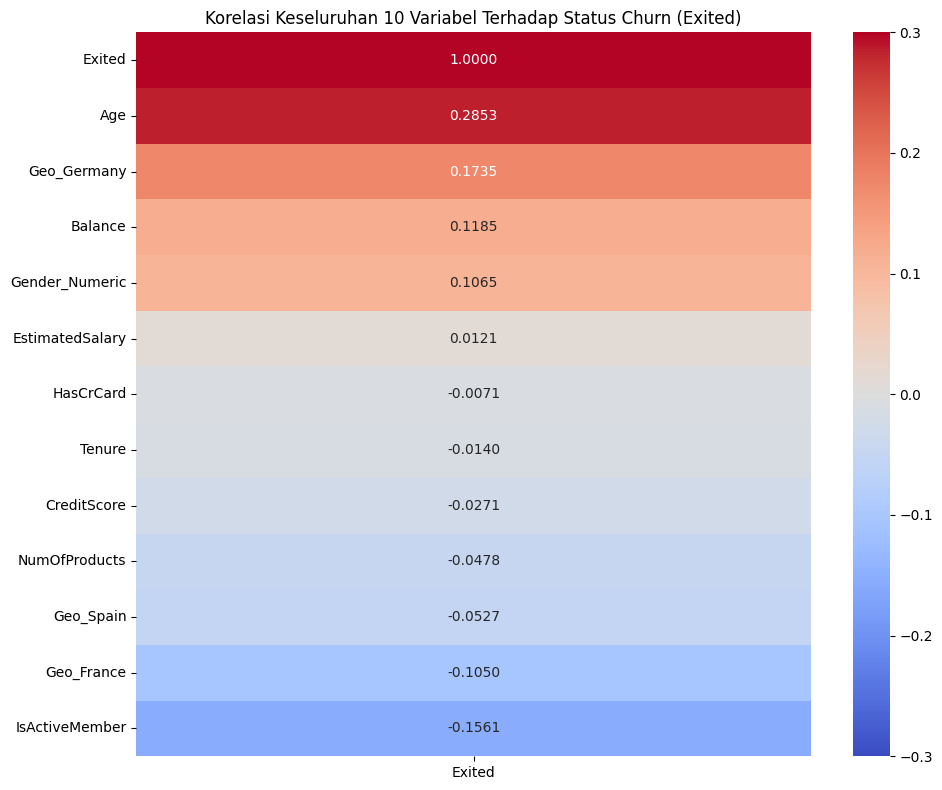

In [21]:
# 2. Encoding Variabel Teks (Gender & Geography)
df_raw['Gender_Numeric'] = df_raw['Gender'].map({'Female': 1, 'Male': 0})
geo_dummies = pd.get_dummies(df_raw['Geography'], prefix='Geo').astype(int)

# 3. Gabungkan seluruh kolom
df_all = pd.concat([df_raw, geo_dummies], axis=1)

# List variabel numerik lengkap
cols = [
    'CreditScore', 'Geo_France', 'Geo_Germany', 'Geo_Spain',
    'Gender_Numeric', 'Age', 'Tenure', 'Balance',
    'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited'
]

# 4. Hitung Matriks Korelasi
corr_matrix = df_all[cols].corr()

# 5. Visualisasi Heatmap (Korelasi Keseluruhan)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix[['Exited']].sort_values(by='Exited', ascending=False),
            annot=True, fmt=".4f", cmap='coolwarm', vmin=-0.3, vmax=0.3)
plt.title('Korelasi Keseluruhan 10 Variabel Terhadap Status Churn (Exited)', fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
balance_summary = df_raw.groupby('Exited').agg(
    Total_Nasabah=('Balance', 'count'),
    Avg_Balance=('Balance', lambda x: round(x.mean(), 2)),
    Median_Balance=('Balance', lambda x: round(x.median(), 2)),
    Total_Volume=('Balance', lambda x: round(x.sum(), 2))
).reset_index()

print(balance_summary)

   Exited  Total_Nasabah  Avg_Balance  Median_Balance  Total_Volume
0       0           7963     72745.30        92072.68  5.792708e+08
1       1           2037     91108.54       109349.29  1.855881e+08


/tmp/ipykernel_4468/2563877894.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_raw, x='Geography', y='Exited', ci=None, palette='viridis')
/tmp/ipykernel_4468/2563877894.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_raw, x='Geography', y='Exited', ci=None, palette='viridis')
/tmp/ipykernel_4468/2563877894.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df_raw, x='Age', hue='Exited', common_norm=False, shade=True, palette='tab10')


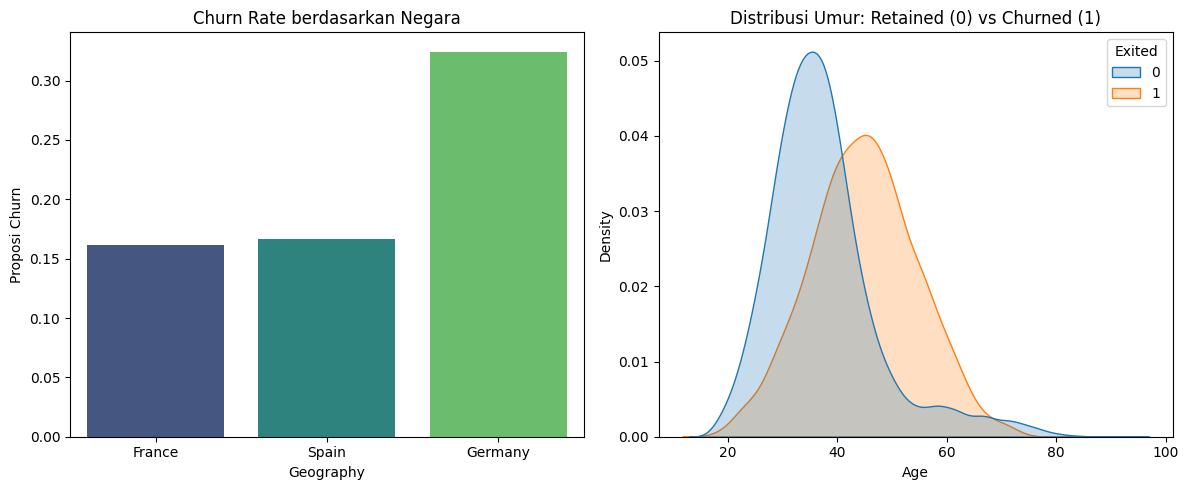

In [12]:
# 4. Visualisasi Dasar (EDA Plot)
plt.figure(figsize=(12, 5))

# Plot 1: Churn Rate per Negara
plt.subplot(1, 2, 1)
sns.barplot(data=df_raw, x='Geography', y='Exited', ci=None, palette='viridis')
plt.title('Churn Rate berdasarkan Negara')
plt.ylabel('Proposi Churn')

# Plot 2: Distribusi Umur berdasarkan Status Churn
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_raw, x='Age', hue='Exited', common_norm=False, shade=True, palette='tab10')
plt.title('Distribusi Umur: Retained (0) vs Churned (1)')

plt.tight_layout()
plt.show()

In [15]:
# Membuat kolom turunan kelompok umur
df_raw["Age_Group"] = pd.cut(df_raw["Age"], bins=[0, 30, 40, 50, 100], labels=["<30", "30-40", "41-50", ">50"])

In [20]:
# Meringkas statistik per kelompok umur
summary = df_raw.groupby("Age_Group").agg(
    Total_Nasabah=("Exited", "count"),
    Total_Churn=("Exited", "sum"),
    Churn_Rate_Pct=("Exited", lambda x: (x.mean() * 100).round(2)),
    Avg_Balance=("Balance", lambda x: x.mean().round(2))
)
summary.reset_index(inplace=True)
print(summary)

  Age_Group  Total_Nasabah  Total_Churn  Churn_Rate_Pct  Avg_Balance
0       <30           1968          148            7.52     73198.76
1     30-40           4451          538           12.09     75583.36
2     41-50           2320          788           33.97     79122.19
3       >50           1261          563           44.65     79951.38


/tmp/ipykernel_4468/2262477859.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df_raw.groupby("Age_Group").agg(


In [19]:
# Mengurutkan dari Churn Rate tertinggi ke terendah
summary_sorted = summary.sort_values("Churn_Rate_Pct", ascending=False)
print(summary_sorted)

           Total_Nasabah  Total_Churn  Churn_Rate_Pct  Avg_Balance
Age_Group                                                         
>50                 1261          563           44.65     79951.38
41-50               2320          788           33.97     79122.19
30-40               4451          538           12.09     75583.36
<30                 1968          148            7.52     73198.76


Temuan

Dari hasil pengelompokan berikut churn rate yang sangat drastis seiring bertambahnya usia:

< 30 Tahun: Churn Rate rendah (7.5%) -> Low Risk
30-40 Tahun: Churn Rate sedang (12.1%) -> Moderate Risk
41-50 Tahun: Churn Rate tinggi (34.0%) -> High Risk
> 50 Tahun: Churn Rate paling ekstrem (44.7%) -> Critical Risk (Hampir 1 dari 2 nasabah usia >50 tahun memilih keluar dari bank).

INSIGHT

Nasabah di kelompok usia senior (41-50 dan >50 tahun) memiliki rata-rata saldo (Average Balance) yang jauh lebih tinggi (berada di kisaran $79,000-$80,000) dibandingkan kelompok usia muda.

Dampak Bisnis (Business Impact): Churn pada segmen usia tua ini merupakan kerugian finansial besar (high revenue loss) bagi bank, karena yang pergi adalah nasabah-nasabah dengan simpanan dana paling besar (high-value customers).

REKOMENDASI

Retain High-Value Senior Customers:

1. Buat program customer loyalty atau layanan khusus (seperti Dedicated Wealth Management, bunga deposito kompetitif, atau kemudahan perencanaan pensiun) yang disesuaikan untuk kebutuhan nasabah usia 40 tahun ke atas.

2. Digital Banking Adaptation:
Evaluasi apakah aplikasi mobile banking atau layanan digital bank terlalu rumit bagi nasabah usia lanjut, sehingga mendorong mereka berpindah ke bank kompetitor.
